Numero de formas detectadas: 2
Area promedio: 55694.5
Perimetro promedio: 2487.8864247202873


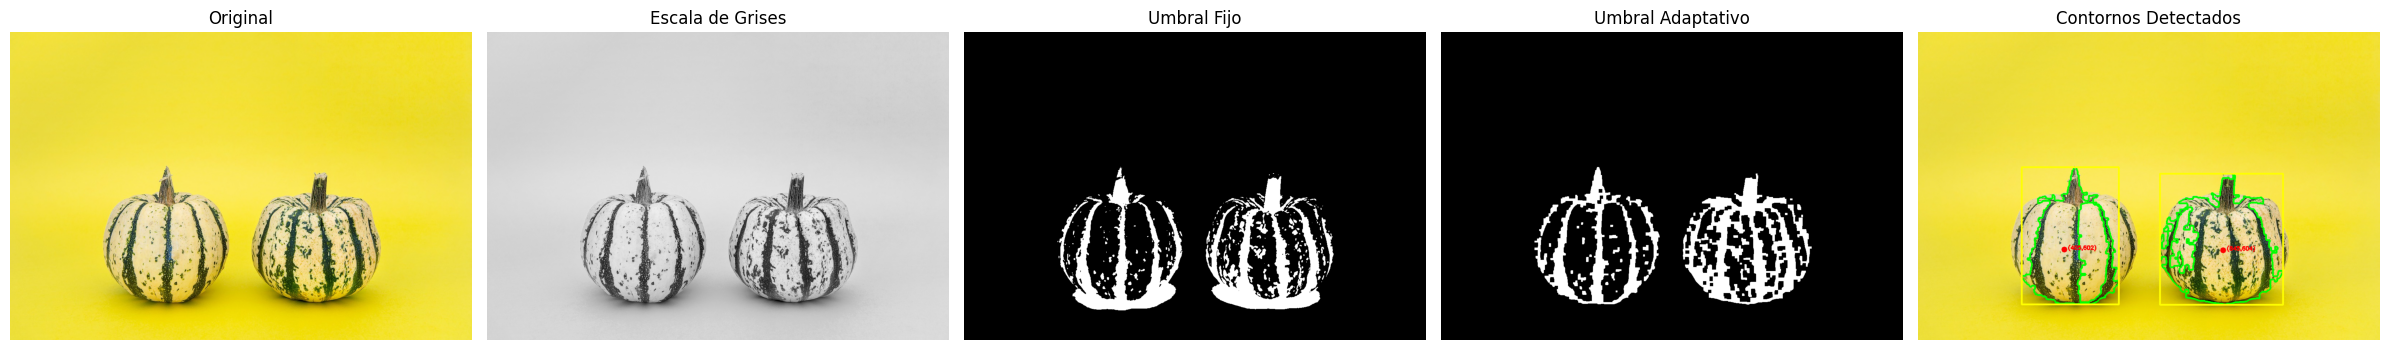

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CARGAR IMAGEN
# =========================================================

imagen = cv2.imread("imagen.jpg")

if imagen is None:
    raise Exception("No se pudo cargar la imagen")

# Imagen original RGB
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

# =========================================================
# ESCALA DE GRISES
# =========================================================

gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

# =========================================================
# SUAVIZADO
# =========================================================

blur = cv2.GaussianBlur(
    gris,
    (5, 5),
    0
)

# =========================================================
# UMBRAL FIJO
# =========================================================

_, umbral_fijo = cv2.threshold(
    blur,
    170,
    255,
    cv2.THRESH_BINARY_INV
)

# =========================================================
# UMBRAL ADAPTATIVO
# =========================================================

umbral_adaptativo = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    8
)

# =========================================================
# LIMPIEZA MORFOLOGICA
# =========================================================

kernel = np.ones((5,5), np.uint8)

mascara = cv2.morphologyEx(
    umbral_adaptativo,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

mascara = cv2.morphologyEx(
    mascara,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

# =========================================================
# DETECCION DE CONTORNOS
# =========================================================

contornos, _ = cv2.findContours(
    mascara,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Copia para dibujar
resultado = imagen_rgb.copy()

# =========================================================
# METRICAS
# =========================================================

areas = []
perimetros = []

# =========================================================
# RECORRER CONTORNOS
# =========================================================

for contorno in contornos:

    area = cv2.contourArea(contorno)

    # Ignorar ruido
    if area < 5000:
        continue

    perimetro = cv2.arcLength(contorno, True)

    areas.append(area)
    perimetros.append(perimetro)

    # =====================================================
    # DIBUJAR CONTORNO
    # =====================================================

    cv2.drawContours(
        resultado,
        [contorno],
        -1,
        (0, 255, 0),
        3
    )

    # =====================================================
    # CENTRO DE MASA
    # =====================================================

    momentos = cv2.moments(contorno)

    if momentos["m00"] != 0:

        cx = int(momentos["m10"] / momentos["m00"])
        cy = int(momentos["m01"] / momentos["m00"])

        cv2.circle(
            resultado,
            (cx, cy),
            8,
            (255, 0, 0),
            -1
        )

        cv2.putText(
            resultado,
            f"({cx},{cy})",
            (cx + 10, cy),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2
        )

    # =====================================================
    # BOUNDING BOX
    # =====================================================

    x, y, w, h = cv2.boundingRect(contorno)

    cv2.rectangle(
        resultado,
        (x, y),
        (x+w, y+h),
        (255, 255, 0),
        3
    )

# =========================================================
# METRICAS FINALES
# =========================================================

numero_formas = len(areas)

area_promedio = (
    np.mean(areas)
    if len(areas) > 0 else 0
)

perimetro_promedio = (
    np.mean(perimetros)
    if len(perimetros) > 0 else 0
)

print("================================")
print("Numero de formas detectadas:", numero_formas)
print("Area promedio:", area_promedio)
print("Perimetro promedio:", perimetro_promedio)
print("================================")

# =========================================================
# VISUALIZACION
# =========================================================

fig, axes = plt.subplots(1, 5, figsize=(24,6))

axes[0].imshow(imagen_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(gris, cmap='gray')
axes[1].set_title("Escala de Grises")
axes[1].axis("off")

axes[2].imshow(umbral_fijo, cmap='gray')
axes[2].set_title("Umbral Fijo")
axes[2].axis("off")

axes[3].imshow(mascara, cmap='gray')
axes[3].set_title("Umbral Adaptativo")
axes[3].axis("off")

axes[4].imshow(resultado)
axes[4].set_title("Contornos Detectados")
axes[4].axis("off")

plt.tight_layout()
plt.show()